# 📧 Email/SMS Spam Detection Project
This notebook demonstrates a comprehensive comparison between **Naive Bayes** and **Support Vector Machine (SVM)** models using **CountVectorizer** and **TF-IDF Vectorizer**.

##  Step 1: Import Libraries

In [34]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

##  Step 2: Load Dataset

In [35]:
# Load the dataset (Make sure 'spam.csv' is in the same directory)
df = pd.read_csv('spam.csv')

# Preprocess: Map categories to binary values (spam = 1, ham = 0)
df['spam'] = df['Category'].apply(lambda x: 1 if x == 'spam' else 0)

# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(df['Message'], df['spam'], test_size=0.25, random_state=42)

In [36]:
df.head()

,Category,Message,spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
 2   spam      5572 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 130.7+ KB


In [38]:
df.Category.value_counts()

,count
Category,
ham,4825
spam,747


##  Step 3: Feature Extraction (Vectorization)

In [39]:
# 1. Initialize CountVectorizer
cv = CountVectorizer()
X_train_cv = cv.fit_transform(X_train)
X_test_cv = cv.transform(X_test)

# 2. Initialize TfidfVectorizer
tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

##  Step 4: Multinomial Naive Bayes Classification Part

In [40]:
print("--- Training Naive Bayes Models ---\n")

# Method A: CountVectorizer + Naive Bayes
model_nb_cv = MultinomialNB()
model_nb_cv.fit(X_train_cv, y_train) # Training with sparse matrix directly to avoid warnings
accuracy_nb_cv = model_nb_cv.score(X_test_cv, y_test)
print(f"1. CountVectorizer + Naive Bayes Accuracy: {accuracy_nb_cv * 100:.2f}%")

# Method B: TF-IDF + Naive Bayes
model_nb_tfidf = MultinomialNB()
model_nb_tfidf.fit(X_train_tfidf, y_train)
accuracy_nb_tfidf = model_nb_tfidf.score(X_test_tfidf, y_test)
print(f"2. TF-IDF + Naive Bayes Accuracy: {accuracy_nb_tfidf * 100:.2f}%")

--- Training Naive Bayes Models ---

1. CountVectorizer + Naive Bayes Accuracy: 98.85%
2. TF-IDF + Naive Bayes Accuracy: 96.27%


##  Step 5: Support Vector Machine (SVM) Classification Part

In [41]:
print("--- Training SVM (LinearSVC) Models ---\n")

# Method C: CountVectorizer + SVM
model_svm_cv = LinearSVC()
model_svm_cv.fit(X_train_cv, y_train)
accuracy_svm_cv = model_svm_cv.score(X_test_cv, y_test)
print(f"3. CountVectorizer + SVM Accuracy: {accuracy_svm_cv * 100:.2f}%")

# Method D: TF-IDF + SVM
model_svm_tfidf = LinearSVC()
model_svm_tfidf.fit(X_train_tfidf, y_train)
accuracy_svm_tfidf = model_svm_tfidf.score(X_test_tfidf, y_test)
print(f"4. TF-IDF + SVM Accuracy: {accuracy_svm_tfidf * 100:.2f}%")

--- Training SVM (LinearSVC) Models ---

3. CountVectorizer + SVM Accuracy: 98.64%
4. TF-IDF + SVM Accuracy: 99.07%


##  Step 6: Model Evaluation & Comparative Performance Dashboard

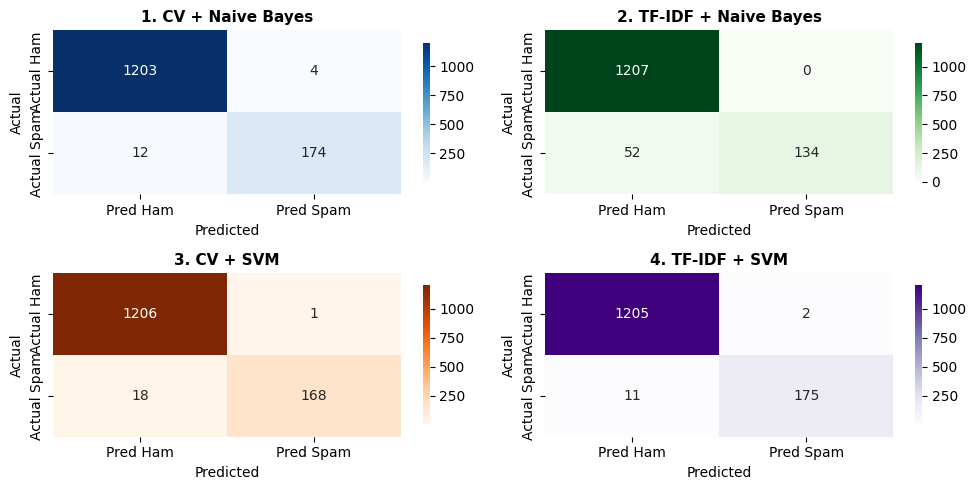

In [42]:
# Generate test predictions for ALL 4 configurations
y_pred_nb_cv = model_nb_cv.predict(X_test_cv)
y_pred_nb_tfidf = model_nb_tfidf.predict(X_test_tfidf)
y_pred_svm_cv = model_svm_cv.predict(X_test_cv)
y_pred_svm_tfidf = model_svm_tfidf.predict(X_test_tfidf)

# Compute confusion matrices for all 4 combinations
cm_nb_cv = confusion_matrix(y_test, y_pred_nb_cv)
cm_nb_tfidf = confusion_matrix(y_test, y_pred_nb_tfidf)
cm_svm_cv = confusion_matrix(y_test, y_pred_svm_cv)
cm_svm_tfidf = confusion_matrix(y_test, y_pred_svm_tfidf)

fig, axes = plt.subplots(2, 2, figsize=(10, 5))

# 1. CountVectorizer + Naive Bayes (Blue)
sns.heatmap(cm_nb_cv, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], cbar_kws={'shrink': 0.85},
            xticklabels=['Pred Ham', 'Pred Spam'], yticklabels=['Actual Ham', 'Actual Spam'])
axes[0, 0].set_title('1. CV + Naive Bayes', fontsize=11, fontweight='bold')
axes[0, 0].set_xlabel('Predicted')
axes[0, 0].set_ylabel('Actual')

# 2. TF-IDF + Naive Bayes (Greens)
sns.heatmap(cm_nb_tfidf, annot=True, fmt='d', cmap='Greens', ax=axes[0, 1], cbar_kws={'shrink': 0.85},
            xticklabels=['Pred Ham', 'Pred Spam'], yticklabels=['Actual Ham', 'Actual Spam'])
axes[0, 1].set_title('2. TF-IDF + Naive Bayes', fontsize=11, fontweight='bold')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Actual')

# 3. CountVectorizer + SVM (Oranges)
sns.heatmap(cm_svm_cv, annot=True, fmt='d', cmap='Oranges', ax=axes[1, 0], cbar_kws={'shrink': 0.85},
            xticklabels=['Pred Ham', 'Pred Spam'], yticklabels=['Actual Ham', 'Actual Spam'])
axes[1, 0].set_title('3. CV + SVM', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Predicted')
axes[1, 0].set_ylabel('Actual')

# 4. TF-IDF + SVM (Purples)
sns.heatmap(cm_svm_tfidf, annot=True, fmt='d', cmap='Purples', ax=axes[1, 1], cbar_kws={'shrink': 0.85},
            xticklabels=['Pred Ham', 'Pred Spam'], yticklabels=['Actual Ham', 'Actual Spam'])
axes[1, 1].set_title('4. TF-IDF + SVM', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Predicted')
axes[1, 1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

##  Step 7: Final Model Comparison Summary

In [43]:
print("==================== FINAL MODEL COMPARISON ====================")
print(f"1. CountVectorizer + Naive Bayes : {accuracy_nb_cv * 100:.2f}%")
print(f"2. TF-IDF + Naive Bayes          : {accuracy_nb_tfidf * 100:.2f}%")
print(f"3. CountVectorizer + SVM         : {accuracy_svm_cv * 100:.2f}%")
print(f"4. TF-IDF + SVM (LinearSVC)      : {accuracy_svm_tfidf * 100:.2f}%")
print("================================================================")

==================== FINAL MODEL COMPARISON ====================
1. CountVectorizer + Naive Bayes : 98.85%
2. TF-IDF + Naive Bayes          : 96.27%
3. CountVectorizer + SVM         : 98.64%
4. TF-IDF + SVM (LinearSVC)      : 99.07%


##  Step 8: In-depth Performance Evaluation (Precision, Recall, F1-Score)

In [44]:
from sklearn.metrics import classification_report

# 1. Classification Report for CountVectorizer + Naive Bayes
print("==================================================================")
print("📊 CLASSIFICATION REPORT: CV + NAIVE BAYES")
print("==================================================================")
print(classification_report(y_test, y_pred_nb_cv, target_names=['Ham (0)', 'Spam (1)']))

# 2. Classification Report for TF-IDF + Naive Bayes
print("==================================================================")
print("📊 CLASSIFICATION REPORT: TF-IDF + NAIVE BAYES")
print("==================================================================")
print(classification_report(y_test, y_pred_nb_tfidf, target_names=['Ham (0)', 'Spam (1)']))

# 3. Classification Report for CountVectorizer + SVM
print("==================================================================")
print("📊 CLASSIFICATION REPORT: CV + SUPPORT VECTOR MACHINE (SVM)")
print("==================================================================")
print(classification_report(y_test, y_pred_svm_cv, target_names=['Ham (0)', 'Spam (1)']))

# 4. Classification Report for TF-IDF + SVM (Champion Model)
print("==================================================================")
print("📊 CLASSIFICATION REPORT: TF-IDF + SUPPORT VECTOR MACHINE (SVM)")
print("==================================================================")
print(classification_report(y_test, y_pred_svm_tfidf, target_names=['Ham (0)', 'Spam (1)']))

📊 CLASSIFICATION REPORT: CV + NAIVE BAYES
              precision    recall  f1-score   support

     Ham (0)       0.99      1.00      0.99      1207
    Spam (1)       0.98      0.94      0.96       186

    accuracy                           0.99      1393
   macro avg       0.98      0.97      0.97      1393
weighted avg       0.99      0.99      0.99      1393

📊 CLASSIFICATION REPORT: TF-IDF + NAIVE BAYES
              precision    recall  f1-score   support

     Ham (0)       0.96      1.00      0.98      1207
    Spam (1)       1.00      0.72      0.84       186

    accuracy                           0.96      1393
   macro avg       0.98      0.86      0.91      1393
weighted avg       0.96      0.96      0.96      1393

📊 CLASSIFICATION REPORT: CV + SUPPORT VECTOR MACHINE (SVM)
              precision    recall  f1-score   support

     Ham (0)       0.99      1.00      0.99      1207
    Spam (1)       0.99      0.90      0.95       186

    accuracy                       

## Why TF-IDF + SVM Performed Best

TF-IDF emphasizes important and discriminative words by reducing the impact of common terms, which is very useful in spam detection.  
Linear SVM is highly effective for sparse, high-dimensional text features and usually performs well in classification tasks like spam vs ham.  
Together, TF-IDF and SVM provided the best overall performance on the test set, although individual custom predictions can still vary depending on the input text.

##  Step 9: Real-Time Custom Message Prediction (Inference)

*Note: Custom predictions may differ from test-set performance because real-world messages can contain unseen patterns or ambiguous wording.*

In [45]:
# Sample raw messages
emails = [
    'Hey mohan, can we get together to watch football game tomorrow?',
    'Upto 20% discount on parking, exclusive offer just for you. Dont miss this reward!'
]

# Transform text using both vectorizers
emails_cv = cv.transform(emails)
emails_tfidf = tfidf.transform(emails)

# Get predictions from all 4 configurations
pred_nb_cv = model_nb_cv.predict(emails_cv)
pred_nb_tfidf = model_nb_tfidf.predict(emails_tfidf)
pred_svm_cv = model_svm_cv.predict(emails_cv)
pred_svm_tfidf = model_svm_tfidf.predict(emails_tfidf)

# Helper function to convert 1 -> 'spam' and 0 -> 'ham'
def get_status(p):
    return ['spam' if val == 1 else 'ham' for val in p]

# Display predictions in a structured format
for i, email in enumerate(emails):
    print(f"✉️ Message {i+1}: '{email}'")
    print(f"  -> 1. CountVectorizer + Naive Bayes : {get_status(pred_nb_cv)[i]}")
    print(f"  -> 2. TF-IDF + Naive Bayes          : {get_status(pred_nb_tfidf)[i]}")
    print(f"  -> 3. CountVectorizer + SVM         : {get_status(pred_svm_cv)[i]}")
    print(f"  -> 4. TF-IDF + SVM (LinearSVC)      : {get_status(pred_svm_tfidf)[i]}")
    print("-" * 70)

✉️ Message 1: 'Hey mohan, can we get together to watch football game tomorrow?'
  -> 1. CountVectorizer + Naive Bayes : ham
  -> 2. TF-IDF + Naive Bayes          : ham
  -> 3. CountVectorizer + SVM         : ham
  -> 4. TF-IDF + SVM (LinearSVC)      : ham
----------------------------------------------------------------------
✉️ Message 2: 'Upto 20% discount on parking, exclusive offer just for you. Dont miss this reward!'
  -> 1. CountVectorizer + Naive Bayes : spam
  -> 2. TF-IDF + Naive Bayes          : ham
  -> 3. CountVectorizer + SVM         : ham
  -> 4. TF-IDF + SVM (LinearSVC)      : ham
----------------------------------------------------------------------
